Total scans: 75

DATASET
Shape: (75, 32)

Room distribution:
room
kitchen    21
hallway    20
lab        19
blinds     15
Name: count, dtype: int64

5-FOLD CROSS-VALIDATION
Mean accuracy: 0.9867
Std deviation: 0.0267

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      blinds       1.00      1.00      1.00        15
     hallway       1.00      1.00      1.00        20
     kitchen       1.00      0.95      0.98        21
         lab       0.95      1.00      0.97        19

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



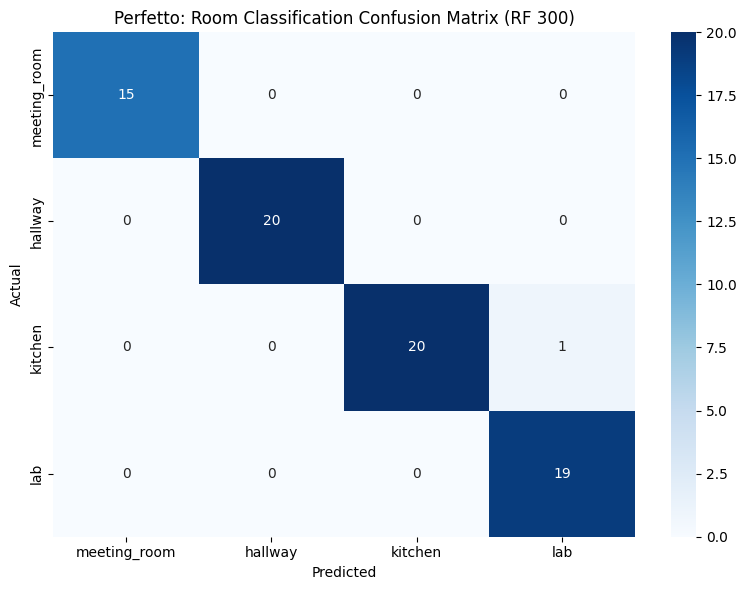


FEATURE IMPORTANCE
                                 feature  importance
0               gpu_util_diff_first_last    0.104452
26                          gpu_util_p90    0.078318
22                        app_rss_mb_p25    0.075301
6                         gpu_util_first    0.065466
19                         gpu_util_last    0.058515
3               Avg Preemption Delay_p75    0.052430
23                       app_vss_mb_mean    0.049702
1               Avg Preemption Delay_std    0.045797
20                          gpu_util_max    0.045486
4                           gpu_util_std    0.039181
10                           gpu_util_cv    0.039162
8               Avg Preemption Delay_max    0.038937
5               Avg Preemption Delay_p90    0.037833
9             Avg Preemption Delay_range    0.033151
11                        gpu_util_range    0.031562
2                           gpu_util_iqr    0.029862
14                     app_rss_mb_median    0.021788
21                        

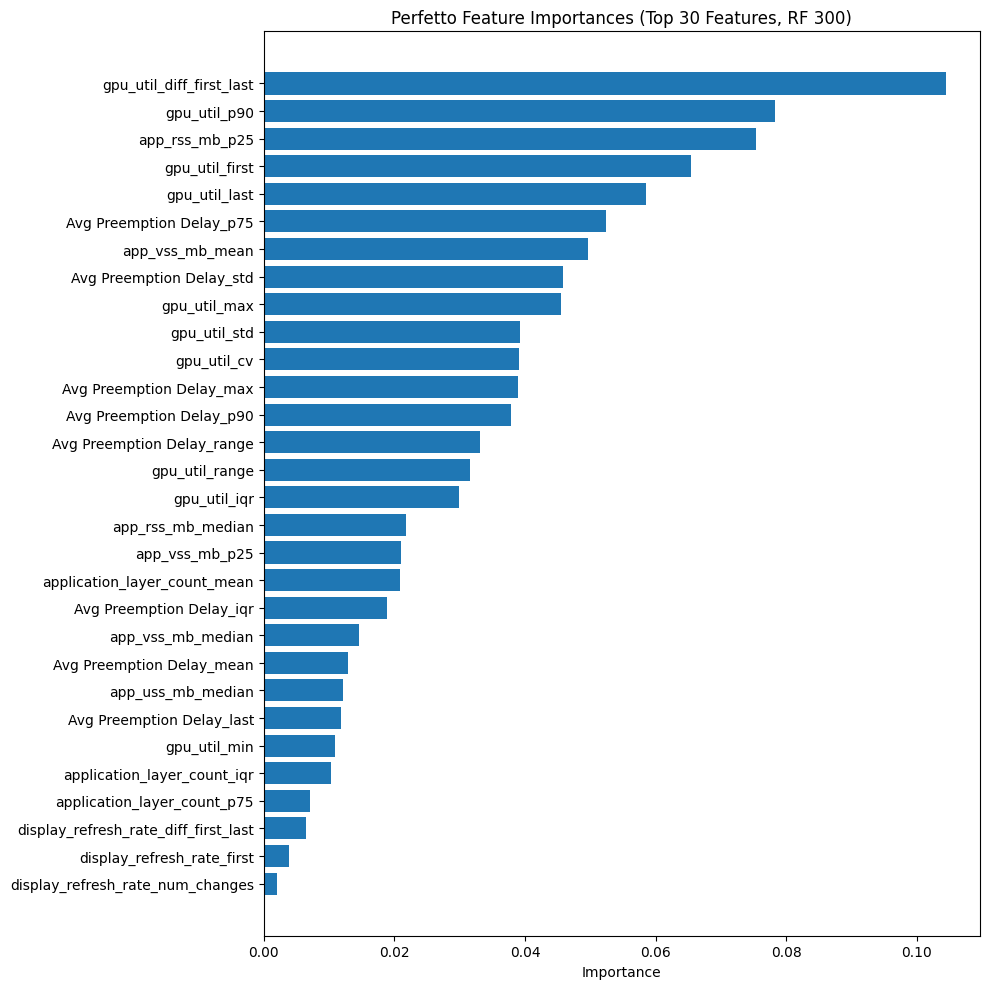

In [6]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# DATA LOADING AND AGGREGATION

base_path = 'meta_scan_csvs/cleaned'
room_files = {
    'kitchen': [],
    'hallway': [],
    'lab': [],
    'blinds': [], # meeting room
}

for room in room_files.keys():
    room_path = os.path.join(base_path, room)
    if os.path.exists(room_path):
        files = [f for f in os.listdir(room_path) if f.endswith('.csv')]
        room_files[room] = [os.path.join(room_path, f) for f in files]

def aggregate_perfetto_scan_extended(filepath):
    """Aggregate a time series scan with extended statistics"""
    df = pd.read_csv(filepath)
    df = df.drop(columns=['Time (s)'], errors='ignore')
    df = df.replace(-1, np.nan)
    
    features = {}
    
    for col in df.columns:
        values = df[col].dropna()
        if len(values) > 0:
            features[f'{col}_mean'] = values.mean()
            features[f'{col}_std'] = values.std()
            features[f'{col}_min'] = values.min()
            features[f'{col}_max'] = values.max()
            features[f'{col}_median'] = values.median()
            features[f'{col}_range'] = values.max() - values.min()
            features[f'{col}_iqr'] = values.quantile(0.75) - values.quantile(0.25)
            features[f'{col}_p10'] = values.quantile(0.10)
            features[f'{col}_p25'] = values.quantile(0.25)
            features[f'{col}_p75'] = values.quantile(0.75)
            features[f'{col}_p90'] = values.quantile(0.90)
            features[f'{col}_skew'] = values.skew()
            features[f'{col}_kurtosis'] = values.kurtosis()
            
            if values.mean() != 0:
                features[f'{col}_cv'] = values.std() / abs(values.mean())
            else:
                features[f'{col}_cv'] = 0
            
            features[f'{col}_first'] = values.iloc[0]
            features[f'{col}_last'] = values.iloc[-1]
            features[f'{col}_diff_first_last'] = values.iloc[-1] - values.iloc[0]
            
            if len(values) > 1:
                x = np.arange(len(values))
                slope = np.polyfit(x, values.values, 1)[0]
                features[f'{col}_trend'] = slope
            else:
                features[f'{col}_trend'] = 0
            
            if len(values) >= 10:
                rolling_std = values.rolling(window=10).std().mean()
                features[f'{col}_rolling_std'] = rolling_std if not pd.isna(rolling_std) else 0
            else:
                features[f'{col}_rolling_std'] = 0
            
            if len(values) > 2:
                diff = np.diff(values.values)
                sign_changes = np.sum(np.diff(np.sign(diff)) != 0)
                features[f'{col}_num_changes'] = sign_changes
            else:
                features[f'{col}_num_changes'] = 0
    
    return features

aggregated_scans_extended = {}
for room, files in room_files.items():
    for filepath in files:
        filename = os.path.basename(filepath)
        aggregated_scans_extended[(room, filename)] = aggregate_perfetto_scan_extended(filepath)

print(f"Total scans: {len(aggregated_scans_extended)}")

# TOP 30 FEATURES

TOP_30_FEATURES = [
    'gpu_util_diff_first_last',
    'Avg Preemption Delay_std',
    'gpu_util_iqr',
    'Avg Preemption Delay_p75',
    'gpu_util_std',
    'Avg Preemption Delay_p90',
    'gpu_util_first',
    'Avg Preemption Delay_iqr',
    'Avg Preemption Delay_max',
    'Avg Preemption Delay_range',
    'gpu_util_cv',
    'gpu_util_range',
    'app_vss_mb_median',
    'Avg Preemption Delay_last',
    'app_rss_mb_median',
    'display_refresh_rate_num_changes',
    'display_refresh_rate_diff_first_last',
    'display_refresh_rate_first',
    'Avg Preemption Delay_mean',
    'gpu_util_last',
    'gpu_util_max',
    'app_vss_mb_p25',
    'app_rss_mb_p25',
    'app_vss_mb_mean',
    'application_layer_count_p75',
    'application_layer_count_iqr',
    'gpu_util_p90',
    'application_layer_count_mean',
    'gpu_util_min',
    'app_uss_mb_median'
]

# BUILD DATASET

perfetto_data_30 = []
for (room, filename), features in aggregated_scans_extended.items():
    row = {'room': room, 'filename': filename}
    for feat in TOP_30_FEATURES:
        row[feat] = features.get(feat, 0)
    perfetto_data_30.append(row)

perfetto_df_30 = pd.DataFrame(perfetto_data_30).fillna(0)

X = perfetto_df_30.drop(columns=['room', 'filename'])
y = perfetto_df_30['room']

print("\nDATASET")
print(f"Shape: {perfetto_df_30.shape}")
print(f"\nRoom distribution:")
print(y.value_counts())

# MODEL TRAINING AND EVALUATION

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

cv_scores = cross_val_score(rf_model, X_scaled, y, cv=kfold, scoring='accuracy')

print("\n5-FOLD CROSS-VALIDATION")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")

y_pred_cv = cross_val_predict(rf_model, X_scaled, y, cv=kfold)

print("\nCLASSIFICATION REPORT")
print(classification_report(y, y_pred_cv))

cm = confusion_matrix(y, y_pred_cv, labels=['blinds', 'hallway', 'kitchen', 'lab'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['meeting_room', 'hallway', 'kitchen', 'lab'],
            yticklabels=['meeting_room', 'hallway', 'kitchen', 'lab'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Perfetto: Room Classification Confusion Matrix (RF 300)')
plt.tight_layout()
plt.savefig('perfetto_confusion_matrix.png')
plt.show()

rf_model.fit(X_scaled, y)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFEATURE IMPORTANCE")
print(feature_importance)

plt.figure(figsize=(10, 10))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Perfetto Feature Importances (Top 30 Features, RF 300)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('perfetto_feature_importance.png')
plt.show()